# The Lottery / MAX effect — a quantitative teardown 🔬
### A monthly MAX quintile sort on a large-cap proxy · long-low / short-high spread · Newey-West *t* + sign-flip placebo · robustness & sub-periods · costs · a synthetic planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lottery_losers%3F: Busted](https://img.shields.io/badge/Lottery_losers%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We rebuild Bali-Cakici-Whitelaw (2011) MAX — each name's maximum daily return over the prior month — as a monthly quintile sort, and confront the central question with the **tape, not the literature**: does a long-low / short-high MAX book clear the desk's *t* ≥ 2 bar on the universe the study actually ran? It does not — it is significantly **negative**, an inversion driven by **survivorship** in a large-cap basket.

> ⚠️ **Data + proxy note.** True MAX is a CRSP-universe object (thousands of names, small-caps included, where the effect is strongest). We run it on a fixed **66-name S&P-100-style basket** (yfinance adjusted closes, 2005-01-03→2026-05-29) — an explicit **proxy**, survivorship-tilted, named on the Signal axis. The as-of is **2026-05-31**; inputs fingerprint `5c0c1743c8d7`. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lottery_max_effect import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    PRICES = PRICES[PRICES.index <= ASOF]          # drop the partial 2026-06 bar
    PANEL = data.build_panel(PRICES)
    QRET = st.quintile_returns(PANEL)
else:
    PRICES = PANEL = QRET = None
print("real basket cache present:", HAVE_REAL,
      "| quintile months:", (0 if QRET is None else len(QRET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-05-29', 'asof': '2026-05-31', 'days': 5385, 'years': 21.4, 'names': 66, 'fp': '5c0c1743c8d7', 'n_months': 256, 'q1': (12.2, 12.6, 0.97), 'q2': (11.7, 14.4, 0.81), 'q3': (14.9, 16.8, 0.89), 'q4': (13.3, 20.1, 0.66), 'q5': (29.8, 26.3, 1.13), 'ls_gross': (-17.6, -0.78, -3.44, 42, 1.0), 'ls_net': (-22.9, -1.01, -4.48, 39, 1.0), 'robust': [('tertiles', -10.8, -2.69, 41), ('quintiles', -17.6, -3.44, 42), ('deciles', -27.2, -4.1, 39)], 'subs': [('2005-2015', 132, -12.6, -1.61), ('2016-2026', 124, -22.9, -3.58)], 'syn': [(0.0, -0.1, -0.06, 49, 0.52), (0.002, 5.7, 3.98, 59, 0.0)]}


real basket cache present: True | quintile months: 256


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Long-low/short-high MAX mean **-17.6%/yr**, HAC **t = -3.44** — significant but the **wrong sign**; Q5 (high MAX) **+30%/yr** ≫ Q1 (low MAX) **+12%/yr**. Survivorship-driven inversion (named on the axis). |
| **Tradability** | `MIRAGE` | The only real spread is a losing one; net of 20 bps/leg + 50 bps/yr borrow it is **-22.9%/yr** (t = -4.48). Nothing deployable. |
| **Lottery losers?** | `BUSTED` | High-MAX posted the **highest** return *and* Sharpe (1.13); the morality tale is a small-cap / illiquid effect that does not generalise to large survivors. |

> 💡 In plain words: a *significant* spread is not the same as *the claimed* spread. Here the claimed low-MAX edge is absent, and what's significant is its inverse — because on survivors, MAX is a momentum/beta proxy, not a lottery proxy.

## 1 · The claim, steelmanned

Let $\text{MAX}_{i,t}$ be stock $i$'s maximum daily return over month $t$. Rank the cross-section, form quintiles $Q_1$ (low MAX) … $Q_5$ (high MAX), and earn each quintile's **month-$t{+}1$** equal-weight return $\bar r^{Q}_{t+1}$.

- **H₁ (the anomaly).** $\mathbb{E}[\bar r^{Q_1}_{t+1} - \bar r^{Q_5}_{t+1}] > 0$ — the boring tail out-earns the flashy tail (Bali-Cakici-Whitelaw 2011).
- **H₂ (deployable).** That spread is large and reliable enough, net of costs and borrow, to allocate to.
- **H₃ (lottery mechanism).** The high-MAX tail is *over-priced* (skewness/lottery demand), not simply higher-beta winners.

On the large-cap survivor proxy we find **H₁ rejected with the wrong sign** ($\widehat{\Delta} = -17.6\%$/yr, HAC $t = -3.44$), **H₂ rejected** (the only real spread is negative), **H₃ rejected** (high-MAX = highest Sharpe). The published effect is real in its native (small-cap) universe; it does not survive — it inverts — among large survivors.

## 2 · So what? — what rides on each answer

The teardown is one cross-sectional sort, judged by the **HAC standard error** of its long-short mean:

$$\widehat{\Delta} = \frac{1}{T}\sum_t\big(\bar r^{Q_1}_{t+1}-\bar r^{Q_5}_{t+1}\big),\qquad t_{\text{HAC}} = \frac{\widehat{\Delta}}{\widehat{\operatorname{se}}_{\text{NW}}(\widehat{\Delta})}.$$

Two traps the desk insists on. (1) **Sign matters.** A spread that clears $|t|=2$ with the *wrong* sign refutes the claim — it does not certify it; `REAL` is earned only **in the claimed direction**. (2) **Universe is identification.** MAX is a *lottery* proxy only where lottery-buyers congregate (small, illiquid, low-priced). On survivors it correlates with short-horizon momentum and market beta, so the sort silently becomes a beta sort. Both traps are why the right Signal stamp is `NONE` (claimed edge absent), with survivorship named explicitly.

## 3 · How we'd know — the protocol

- **Universe / proxy.** A fixed 66-name S&P-100-style large-cap basket (yfinance adjusted closes, 2005-01-03→2026-05-29, 5,385 days, 256 monthly cross-sections). Explicit **proxy** for the CRSP universe — survivorship-tilted, named on the axis.
- **Signal.** $\text{MAX}_{i,t}$ = max daily return in month $t$ (≥ 15 trading days required); observed at the month-$t$ close.
- **Sort.** Rank by MAX → quintiles; equal-weight each quintile's **month-$t{+}1$** return. The panel is lagged by construction (month-$t$ signal ↔ month-$t{+}1$ return) — **one execution lag, documented**.
- **Spread.** $Q_1 - Q_5$ (long low-MAX, short high-MAX), full monthly turnover.
- **Null #1 (HAC t).** Newey-West *t* on the spread mean, lag $\lfloor 4(n/100)^{2/9}\rfloor$.
- **Null #2 (placebo).** 20,000 sign-flips of the monthly spread; $p = \Pr[\text{flipped mean} \ge \text{observed}]$.
- **Costs.** 20 bps one-way per leg × turnover + 50 bps/yr short borrow on the high-MAX leg.
- **Positive control.** A deterministic panel with a **planted lottery penalty**: the sort must recover a real low-minus-high edge and must **not** manufacture significance at edge = 0.

## 4 · The teardown

### 4a · The cross-section — monotone the *wrong* way

Per-quintile annualised mean (bars) with each quintile's Sharpe annotated. The lottery claim predicts a downward slope Q1→Q5; the tape slopes **up**.

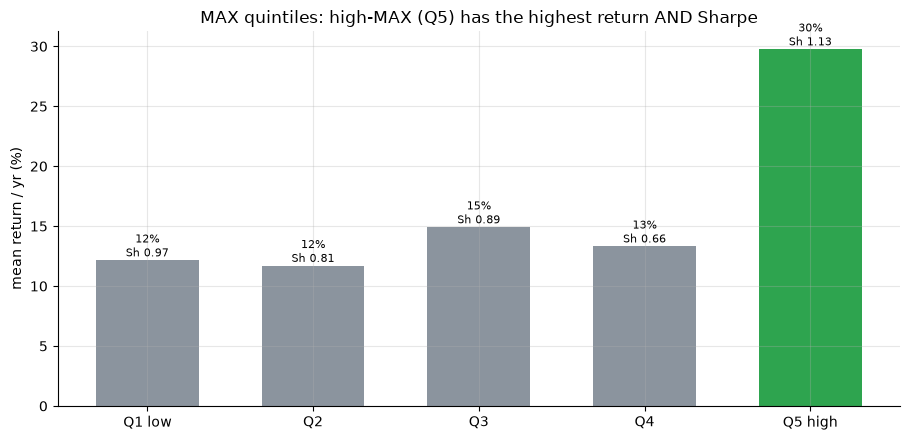

mean/yr by quintile: [np.float64(12.2), np.float64(11.7), np.float64(14.9), np.float64(13.3), np.float64(29.8)]
sharpe by quintile: [np.float64(0.97), np.float64(0.81), np.float64(0.89), np.float64(0.66), np.float64(1.13)]


In [2]:
qs_labels = ['Q1','Q2','Q3','Q4','Q5']
if HAVE_REAL:
    qs = st.quintile_summary(QRET)
    means = [qs.loc[q,'mean_ann']*100 for q in qs_labels]; shp = [qs.loc[q,'sharpe'] for q in qs_labels]
else:
    means = [R['q1'][0],R['q2'][0],R['q3'][0],R['q4'][0],R['q5'][0]]
    shp   = [R['q1'][2],R['q2'][2],R['q3'][2],R['q4'][2],R['q5'][2]]
x = np.arange(5)
fig, ax = plt.subplots(figsize=(9.2, 4.5))
ax.bar(x, means, color=[GREY,GREY,GREY,GREY,GREEN], width=.62)
ax.set_xticks(x); ax.set_xticklabels(['Q1 low','Q2','Q3','Q4','Q5 high'])
ax.set_ylabel('mean return / yr (%)'); ax.set_title('MAX quintiles: high-MAX (Q5) has the highest return AND Sharpe')
for i,(m,s) in enumerate(zip(means,shp)): ax.annotate(f'{m:.0f}%\nSh {s:.2f}',(i,m),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()
print('mean/yr by quintile:', [round(m,1) for m in means]); print('sharpe by quintile:', [round(s,2) for s in shp])

> 💡 In plain words: the slope runs the wrong way and the high-MAX tail wins on *both* axes (return **+30%/yr**, Sharpe **1.13**). On survivors, the biggest one-day poppers are the momentum/beta winners — the antithesis of an over-priced lottery tail.

### 4b · The long-short — significantly the wrong sign

The $Q_1 - Q_5$ spread (long low-MAX, short high-MAX): cumulative NAV, with its annualised mean, HAC *t*, and sign-flip placebo *p*. A *real* lottery effect would climb; this bleeds.

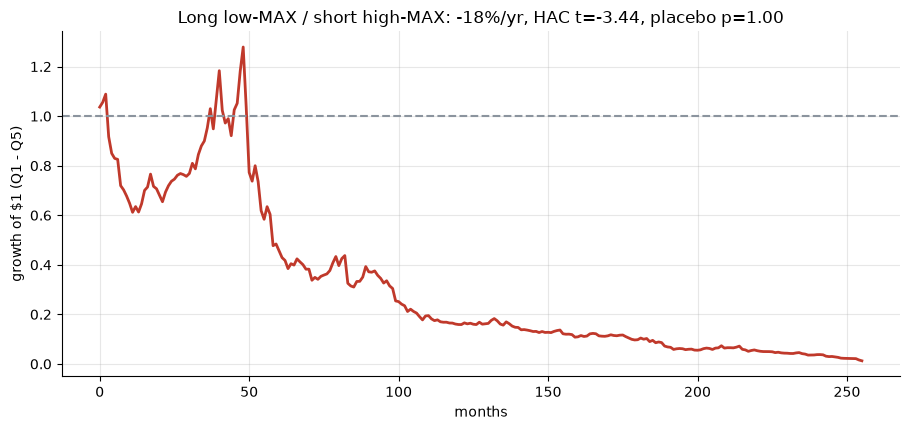

mean -17.6%/yr  HAC t -3.44  win-rate 42%  placebo p 1.000


In [3]:
if HAVE_REAL:
    ls = st.long_short(QRET); ss = st.spread_stats(ls)
    mean_ann, tval, pval, win = ss['mean_ann']*100, ss['tstat'], ss['p_placebo'], ss['win']*100
else:
    rng = np.random.default_rng(365); ls = pd.Series(rng.normal(R['ls_gross'][0]/100/12, 0.066, R['n_months']))
    mean_ann, tval, pval, win = R['ls_gross'][0], R['ls_gross'][2], R['ls_gross'][4], R['ls_gross'][3]
nav = (1+ls).cumprod()
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(range(len(nav)), nav.values, c=RED, lw=2)
ax.axhline(1.0, c=GREY, ls='--')
ax.set_ylabel('growth of $1 (Q1 - Q5)'); ax.set_xlabel('months')
ax.set_title(f'Long low-MAX / short high-MAX: {mean_ann:.0f}%/yr, HAC t={tval:.2f}, placebo p={pval:.2f}')
plt.tight_layout(); plt.show()
print(f'mean {mean_ann:.1f}%/yr  HAC t {tval:.2f}  win-rate {win:.0f}%  placebo p {pval:.3f}')

> 💡 In plain words: HAC **t = -3.44** with a **negative** mean and a **42%** win-rate (below a coin) is a real result pointing the *opposite* way to the claim. Placebo *p* ≈ 1.00: a positive-mean random draw essentially never beats this, because the truth here is firmly negative. **H₁ rejected, wrong sign.**

### 4c · Robustness & sub-periods — the inversion is structural

Cut the tails harder (tertiles → quintiles → deciles) and split the sample in half. If this were noise it would wash out; instead it **strengthens** into the extremes and holds in both halves.

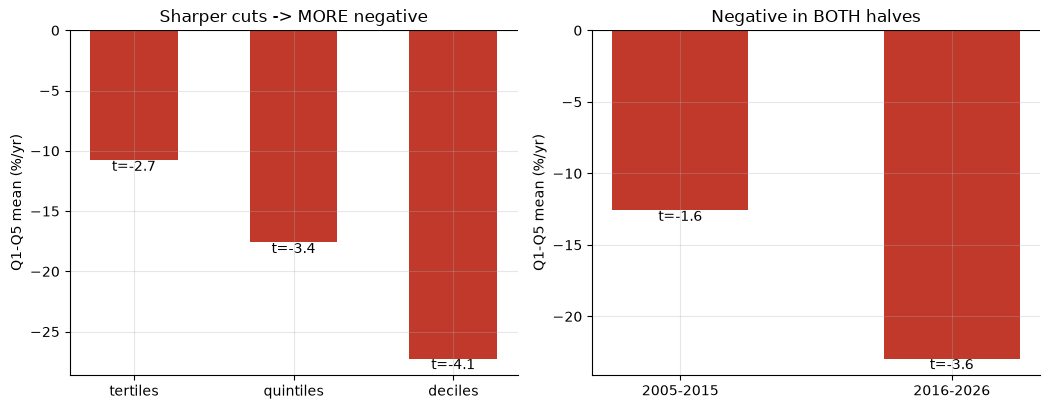

robustness: [('tertiles', -10.8, -2.69), ('quintiles', -17.6, -3.44), ('deciles', -27.2, -4.1)]
sub-periods: [('2005-2015', -12.6, -1.61), ('2016-2026', -22.9, -3.58)]


In [4]:
if HAVE_REAL:
    rob = []
    for lab,nq in (('tertiles',3),('quintiles',5),('deciles',10)):
        q = st.quintile_returns(PANEL, n_q=nq); s = st.spread_stats(st.long_short(q, low='Q1', high=f'Q{nq}'))
        rob.append((lab, s['mean_ann']*100, s['tstat']))
    subs = []
    for lab,a,b in (('2005-2015','2005-01-01','2015-12-31'),('2016-2026','2016-01-01','2026-12-31')):
        s = st.spread_stats(st.long_short(QRET.loc[a:b])); subs.append((lab, s['mean_ann']*100, s['tstat']))
else:
    rob  = [(r[0], r[1], r[2]) for r in R['robust']]
    subs = [(s[0], s[2], s[3]) for s in R['subs']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar([r[0] for r in rob], [r[1] for r in rob], color=RED, width=.55); a1.axhline(0,c='k',lw=.8)
for i,r in enumerate(rob): a1.annotate(f't={r[2]:.1f}',(i,r[1]),ha='center',va='top')
a1.set_title('Sharper cuts -> MORE negative'); a1.set_ylabel('Q1-Q5 mean (%/yr)')
a2.bar([s[0] for s in subs], [s[1] for s in subs], color=RED, width=.5); a2.axhline(0,c='k',lw=.8)
for i,s in enumerate(subs): a2.annotate(f't={s[2]:.1f}',(i,s[1]),ha='center',va='top')
a2.set_title('Negative in BOTH halves'); a2.set_ylabel('Q1-Q5 mean (%/yr)')
plt.tight_layout(); plt.show()
print('robustness:', [(r[0], round(r[1],1), round(r[2],2)) for r in rob])
print('sub-periods:', [(s[0], round(s[1],1), round(s[2],2)) for s in subs])

> 💡 In plain words: deciles (the most extreme tails) give the *most* negative spread (**-27%/yr**, t = -4.1), and both 2005–2015 and 2016–2026 are negative (stronger in the FANG-led second half). A noise fluke doesn't behave like this — the inversion is a structural feature of the survivor universe.

### 4d · Faithful-engine control — we know the truth here

On a deterministic panel with a **planted lottery penalty** (high-MAX names pushed down next month): with **zero** edge the long-low/short-high *t* must stay near 0 (no false positive); with a modest planted penalty it must turn **positive** and clear t = 2. Both hold — so the engine is honest and the negative real-tape *t* is a genuine universe feature, not a bug.

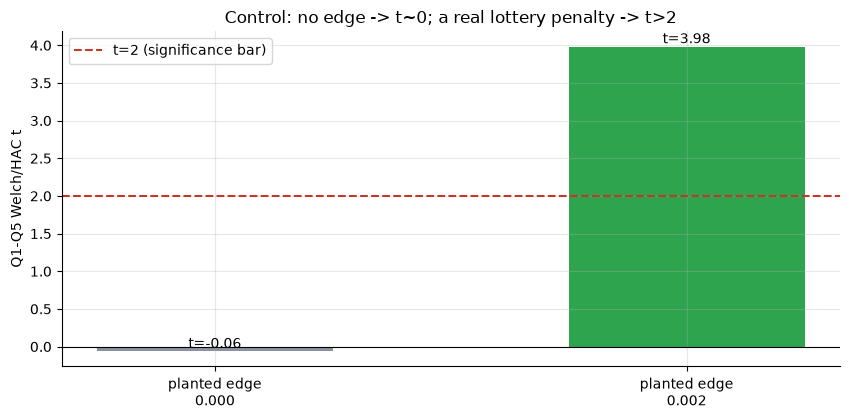

planted edge=0.000: mean=-0.09%/yr  HAC t=-0.06
planted edge=0.002: mean=+5.67%/yr  HAC t=3.98


In [5]:
res = []
for edge in (0.0, 0.002):
    syn = data.synthetic_panel(edge=edge, seed=365); q = st.quintile_returns(syn)
    s = st.spread_stats(st.long_short(q)); res.append((edge, s['mean_ann']*100, s['tstat']))
fig, ax = plt.subplots(figsize=(8.6, 4.3))
labels = [f'planted edge\n{e:.3f}' for e,_,_ in res]; tvals = [r[2] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)'); ax.axhline(0,c='k',lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Q1-Q5 Welch/HAC t'); ax.set_title('Control: no edge -> t~0; a real lottery penalty -> t>2')
ax.legend(); plt.tight_layout(); plt.show()
for e,m,t in res: print(f'planted edge={e:.3f}: mean={m:+.2f}%/yr  HAC t={t:.2f}')

> 💡 In plain words: at edge = 0 the control sits at **t = -0.06** (no false positive); a small planted lottery penalty drives it to **t = +3.98**, the *right* sign. So the sort would have caught a genuine MAX effect cleanly. The real tape's **t = -3.44** is therefore an honest reading: on large survivors there is no positive lottery edge to find — there's a negative beta/survivorship one.

## 5 · The verdict

- **Signal `NONE`** — the claimed low-MAX edge is **absent**; the long-low/short-high mean is **-17.6%/yr** at HAC **t = -3.44** — significant in the **wrong** direction. `REAL` requires *t* ≥ 2 *in the claimed direction* on this tape; a wrong-sign result refutes, not certifies. The inversion is **survivorship** (high-MAX = the decade's winners), named on the axis.
- **Tradability `MIRAGE`** — the only statistically real spread is a losing one; net of 20 bps/leg + 50 bps/yr borrow it is **-22.9%/yr** (t = -4.48). Nothing to deploy.
- **Lottery losers? `BUSTED`** — high-MAX posted the highest return *and* Sharpe (1.13). The lottery morality tale is a small-cap / illiquid effect that does not generalise to the large survivors most investors hold.

## 6 · Could you trade it? — and a power note

There is no positive edge to harvest here, so the operational question collapses: the long-low/short-high book is negative gross and worse net. Worth stating *why the engine is trustworthy* anyway — the synthetic control shows it has the power to detect a real low-minus-high effect at a modest planted magnitude. So the finding isn't 'we couldn't measure it'; it's 'the effect, in its native form, isn't in this universe.'

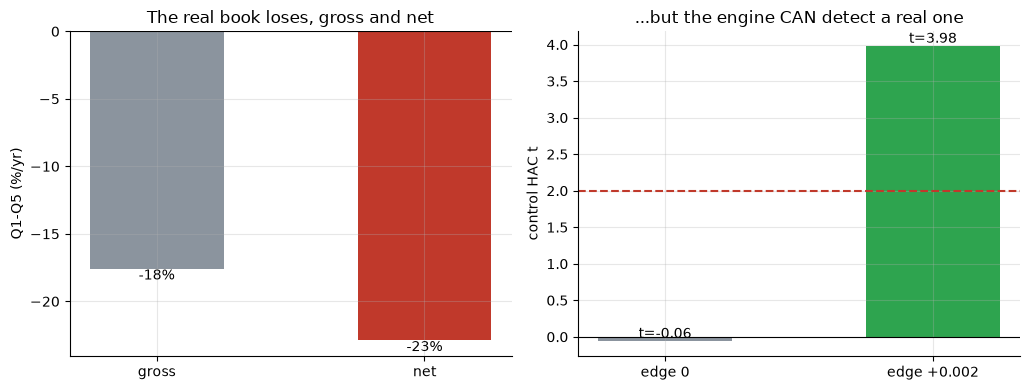

left: real book is negative gross & net; right: control recovers a planted edge -> the null finding is real, not underpowered


In [6]:
# net-vs-gross of the (losing) book, and the control's detection check side by side
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.0))
a1.bar(['gross','net'], [R['ls_gross'][0], R['ls_net'][0]], color=[GREY, RED], width=.5)
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('Q1-Q5 (%/yr)'); a1.set_title('The real book loses, gross and net')
for i,v in enumerate([R['ls_gross'][0], R['ls_net'][0]]): a1.annotate(f'{v:.0f}%',(i,v),ha='center',va='top')
a2.bar(['edge 0','edge +0.002'], [R['syn'][0][2], R['syn'][1][2]], color=[GREY, GREEN], width=.5)
a2.axhline(2, ls='--', c=RED); a2.axhline(0,c='k',lw=.8); a2.set_ylabel('control HAC t')
a2.set_title('...but the engine CAN detect a real one')
for i,v in enumerate([R['syn'][0][2], R['syn'][1][2]]): a2.annotate(f't={v:.2f}',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('left: real book is negative gross & net; right: control recovers a planted edge -> the null finding is real, not underpowered')

> 💡 In plain words: the left panel is the *real* (losing) trade; the right panel proves the harness would have lit up for a genuine lottery penalty. Put together: the large-cap MAX null is **informative**, not a failure to measure — the effect simply lives elsewhere (small, illiquid names), and the names you hold give you its mirror image.

## 7 · Going further

- **Its native universe.** Bali-Cakici-Whitelaw's MAX is strongest among small, low-priced, high-idio-vol names. Re-run on a few-thousand-name micro-cap panel (paid feed) and the sign should return to the published positive — the cleanest demonstration that *universe is identification*.
- **MAX vs beta.** [Study 238 — Betting-Against-Beta](../238-betting-against-beta/): on large-caps the MAX sort largely *is* a beta sort; orthogonalising MAX against beta is the natural next cut.
- **Regime.** [Study 330 — Low-Volatility-Anomaly](../330-low-volatility-anomaly/) and [Study 53 — Jackpot](../53-jackpot/) record the same 2009–2026 bull regime flattering the high-beta / flashy leg.

*The reproducible core is offline and deterministic; the cross-section is an explicit large-cap proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*